# Member 2 (ML Engineer) - Báo cáo Tiến độ Lần 2
**Nhiệm vụ:** Chạy Classification Models và Regression Models, tối ưu hóa (GridSearchCV), và xuất đồ thị/chỉ số (Metrics).

### 1. Khai báo các thư viện cần thiết
Cell này thực hiện việc import các thư viện Python chuẩn bị cho việc xử lý dữ liệu, huấn luyện mô hình học máy (Machine Learning), và trực quan hóa kết quả. Các mô hình Phân loại (Classification) và Hồi quy (Regression) cũng được nạp sẵn từ thư viện `scikit-learn`.

In [1]:
# Khai báo các thư viện cần dùng
import os
import time
import pandas as pd
import numpy as np
import joblib # Dùng để lưu và tải các mô hình/pipeline đã huấn luyện
import matplotlib.pyplot as plt
import seaborn as sns

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore') # Tắt các cảnh báo (warnings) không quan trọng để output gọn gàng hơn

**Giải thích chi tiết tác dụng của Code Cell 1:**
- **`pandas`, `numpy`**: Thư viện nền tảng để thao tác và tính toán trên dữ liệu dạng bảng và ma trận.
- **`joblib`**: Rất quan trọng trong ML Engineer, dùng để export/import các pipeline và model có dung lượng lớn một cách tối ưu.
- **`sklearn...`**: Nạp sẵn các thuật toán phân loại (Logistic Regression, Random Forest, v.v.), hồi quy (Linear, Decision Tree) và các hàm đánh giá hiệu suất mô hình (metrics).
- **`warnings.filterwarnings('ignore')`**: Giúp ẩn đi các cảnh báo phiên bản hoặc các lỗi cảnh báo nhỏ của Scikit-learn trong quá trình train, giúp báo cáo dễ nhìn hơn.

### 2. Load Data và Joblib Pipelines
Mục đích của phần này là nạp tập dữ liệu huấn luyện (train) và kiểm thử (test) mà Data Engineer đã lưu dưới định dạng `.parquet`. Đồng thời, tải 2 pipeline (chuỗi các bước xử lý dữ liệu) dành riêng cho bài toán Classification và Regression đã được định nghĩa trước đó.

In [2]:
# Xác định đường dẫn tương đối (Relative path) tới Data
data_dir = "../Data/Raw/"
pipeline_dir = "../Models/Recommendation/"

# Đọc Dữ liệu Train / Test
print("Đang tải dữ liệu...")
# Sử dụng read_parquet để đọc file Parquet (tốc độ đọc nhanh và nén tốt hơn CSV)
df_train = pd.read_parquet(os.path.join(data_dir, "train_data.parquet"))
df_test = pd.read_parquet(os.path.join(data_dir, "test_data.parquet"))
print("Đã load xong bộ dữ liệu (train_data, test_data).")
print("Dữ liệu Train Shape:", df_train.shape)
print("Dữ liệu Test Shape:", df_test.shape)

# Đọc pipelines (thường là ColumnTransformer + Scaler/Encoder)
# Tải lại cấu trúc xử lý dữ liệu đã được fit trước đó
pipeline_clf = joblib.load(os.path.join(pipeline_dir, "pipeline_classification.joblib"))
pipeline_reg = joblib.load(os.path.join(pipeline_dir, "pipeline_regression.joblib"))
print("Đã load xong 2 file pipeline_classification và pipeline_regression.")

Đang tải dữ liệu...
Đã load xong bộ dữ liệu (train_data, test_data).
Dữ liệu Train Shape: (90740, 37)
Dữ liệu Test Shape: (22685, 37)
Đã load xong 2 file pipeline_classification và pipeline_regression.


**Giải thích chi tiết tác dụng của Code Cell 2:**
- Việc sử dụng định dạng **Parquet** thay vì CSV giúp tiết kiệm dung lượng lưu trữ, giữ nguyên được kiểu dữ liệu (data types) và tăng tốc độ đọc/ghi đáng kể.
- Lệnh `joblib.load()` giúp gọi lại các **Pipeline** chứa những phép biến đổi dữ liệu (như chuẩn hóa Scaler, mã hóa Categorical Encoder) đã được Data Engineer xây dựng sẵn. Điều này đảm bảo tính nhất quán: dữ liệu mới đi vào sẽ đi qua đúng các bước biến đổi hệt như lúc huấn luyện.

### 3. Chuẩn bị Feature và Target cho Classification
Cell này thực hiện việc tách dữ liệu thành biến độc lập (X) và biến mục tiêu (y). Biến mục tiêu `review_score` sẽ được biến đổi thành dạng nhị phân (0 và 1) để phù hợp với bài toán phân loại nhị phân (Binary Classification).

In [3]:
# Chuẩn bị X và Y
# Classification Target: review_score (binary >=4 là positive, hoặc multi class 1-5).
# Tùy theo pipeline M1 thiết kế. Giả sử ta chia lại review_score nhị phân:
def prepare_classification_data(df, pipeline):
    # Lấy đúng các cột mà pipeline yêu cầu (đã fit sẵn) thông qua thuộc tính feature_names_in_
    X_raw = df[pipeline.feature_names_in_]
    
    # Chỉ transform, KHÔNG fit_transform vì pipeline đã được huấn luyện với tập dữ liệu gốc, tránh hiện tượng rò rỉ dữ liệu (Data Leakage)
    X = pipeline.transform(X_raw)
    
    # Target của Classification là review_score: Chuyển >=4 thành 1 (tốt), ngược lại thành 0 (chưa tốt)
    y = df['review_score'].apply(lambda x: 1 if x >= 4 else 0).values 
    
    return X, y

print("Trích xuất features Classification qua Pipeline...")
try:
    X_train_clf, y_train_clf = prepare_classification_data(df_train, pipeline_clf)
    X_test_clf, y_test_clf = prepare_classification_data(df_test, pipeline_clf)
    print("Kích thước X_train_clf:", X_train_clf.shape)
except Exception as e:
    print(f"Lỗi extract classification pipeline: {e}")

Trích xuất features Classification qua Pipeline...
Kích thước X_train_clf: (90740, 20)


**Giải thích chi tiết tác dụng của Code Cell 3:**
- **Lấy đúng feature**: Hàm gọi `pipeline.feature_names_in_` để lọc ra chính xác những cột mà pipeline cần xử lý, tránh lỗi thiếu hoặc dư cột.
- **Quy tắc `transform`**: Hàm chỉ dùng `.transform()` mà tuyệt đối không dùng `.fit_transform()`. Điều này cực kỳ quan trọng trong Machine Learning để ngăn chặn rò rỉ thông tin (Data Leakage) từ tập Test sang tập Train.
- **Biến đổi Target**: Điểm đánh giá (review_score) được chuyển từ dạng số sang dạng nhị phân (1/0) đại diện cho Tích cực/Tiêu cực, làm tiền đề để chạy các thuật toán phân loại ở bước sau.

### 4. Khởi tạo, Huấn luyện và Đánh giá các mô hình Phân loại
Cell này thiết lập một từ điển (dictionary) chứa 5 mô hình học máy phổ biến. Sau đó, nó dùng một vòng lặp để lần lượt đưa dữ liệu vào huấn luyện (`fit`), dự đoán (`predict`) và tính toán các chỉ số đánh giá chất lượng mô hình (Accuracy, Precision, Recall, F1, AUC-ROC).

In [4]:
# Define Models for Classification
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gaussian NB': GaussianNB(), # Phải dùng .toarray() với dữ liệu dạng sparse X_train
    'Linear SVC': LinearSVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# DataFrame để lưu kết quả bảng (Mục V.1 Bảng V.1)
clf_results = []

print("Đang huấn luyện các mô hình Phân Loại (Classification)...")
import scipy.sparse
for name, model in clf_models.items():
    print(f"[{name}] Đang train...")
    start_time = time.time()
    
    try:
        # Kiểm tra X_train có phải sparse matrix không, vì GaussianNB không nhận đầu vào là ma trận thưa
        if name == 'Gaussian NB' and scipy.sparse.issparse(X_train_clf):
            model.fit(X_train_clf.toarray(), y_train_clf)
            y_pred = model.predict(X_test_clf.toarray())
            # predict_proba dùng cho các mô hình tính được xác suất, decision_function cho các mô hình dùng ranh giới quyết định (như SVC)
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_clf.toarray())[:, 1]
            else:
                y_prob = model.decision_function(X_test_clf.toarray())
        else:
            model.fit(X_train_clf, y_train_clf)
            y_pred = model.predict(X_test_clf)
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_clf)[:, 1]
            else:
                y_prob = model.decision_function(X_test_clf)
    except Exception as e:
        print(f"Lỗi chạy mô hình {name}: {e}")
        continue
        
    train_time = time.time() - start_time
    
    # Tính các chỉ số đánh giá (Evaluation metrics) để đưa vào bảng tổng hợp
    acc = accuracy_score(y_test_clf, y_pred)
    prec = precision_score(y_test_clf, y_pred, average='macro')
    rec = recall_score(y_test_clf, y_pred, average='macro')
    f1 = f1_score(y_test_clf, y_pred, average='macro')
    try:
        auc = roc_auc_score(y_test_clf, y_prob)
    except:
        auc = np.nan
        
    clf_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision(macro)': prec,
        'Recall(macro)': rec,
        'F1-score(macro)': f1,
        'AUC-ROC': auc,
        'Train time (s)': train_time
    })
    
# Chuyển đổi list kết quả thành DataFrame pandas để hiển thị dưới dạng Bảng đẹp mắt
df_clf_results = pd.DataFrame(clf_results)
df_clf_results

Đang huấn luyện các mô hình Phân Loại (Classification)...
[Logistic Regression] Đang train...
[Random Forest] Đang train...
[Gaussian NB] Đang train...
[Linear SVC] Đang train...
[Gradient Boosting] Đang train...


,Model,Accuracy,Precision(macro),Recall(macro),F1-score(macro),AUC-ROC,Train time (s)
0,Logistic Regression,0.829403,0.817830,0.707514,0.736475,0.755170,0.099317
1,Random Forest,0.831386,0.826878,0.706531,0.736780,0.764072,3.760778
2,Gaussian NB,0.808552,0.753866,0.722464,0.735055,0.719679,0.063125
3,Linear SVC,0.829315,0.819440,0.706073,0.735310,0.754290,0.073146
4,Gradient Boosting,0.832092,0.823154,0.711043,0.740650,0.764328,4.388209


**Giải thích chi tiết tác dụng của Code Cell 4:**
- Vòng lặp `for` giúp tự động hóa quá trình huấn luyện thay vì phải viết code thủ công cho từng mô hình. 
- **Xử lý Sparse Matrix:** Trong NLP hoặc mã hóa One-Hot, dữ liệu thường ở dạng ma trận thưa (nhiều số 0) để tiết kiệm RAM. Thuật toán `GaussianNB` không hỗ trợ dạng này, do đó phải ép kiểu về `.toarray()` (ma trận đặc) trước khi fit.
- Hàm `hasattr(model, "predict_proba")` giúp code không bị lỗi khi một số thuật toán (như LinearSVC) không trả về xác suất (`predict_proba`) mà chỉ trả về khoảng cách đến ranh giới phân lớp (`decision_function`). Xác suất này được dùng để tính chỉ số **AUC-ROC**.
- Kết quả cuối cùng được gom lại vào một bảng `pandas DataFrame` giúp dễ dàng so sánh hiệu năng và thời gian chạy giữa các mô hình.

### 5. Xác định mô hình tốt nhất và Trực quan hóa Confusion Matrix
Dựa vào bảng kết quả ở trên, cell này sẽ tự động tìm ra mô hình có chỉ số AUC-ROC cao nhất, sau đó vẽ Ma trận nhầm lẫn (Confusion Matrix) để xem chi tiết sai số dự đoán và lưu mô hình này lại thành file.

Best Classification Model: Gradient Boosting


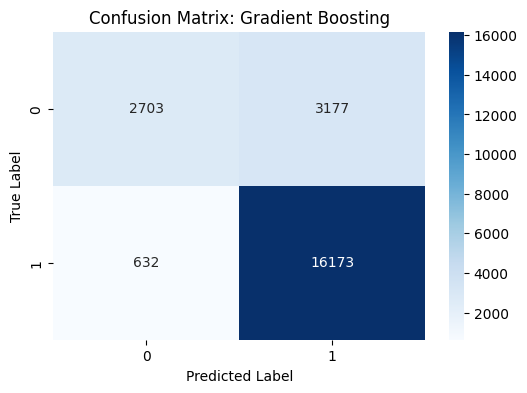

Đã lưu best model Classification tại best_classification_model.joblib


In [5]:
# Tự động chọn mô hình có AUC-ROC cao nhất (sắp xếp giảm dần và lấy dòng đầu tiên)
best_model_name_clf = df_clf_results.sort_values(by='AUC-ROC', ascending=False).iloc[0]['Model']
best_clf_model = clf_models[best_model_name_clf]
print(f"Best Classification Model: {best_model_name_clf}")

# Predict cho best model (Có kiểm tra xử lý sparse matrix riêng cho Gaussian NB)
if best_model_name_clf == 'Gaussian NB' and scipy.sparse.issparse(X_test_clf):
    y_pred_best = best_clf_model.predict(X_test_clf.toarray())
else:
    y_pred_best = best_clf_model.predict(X_test_clf)

# Plot Confusion Matrix: So sánh nhãn thực tế và nhãn dự đoán
cm = confusion_matrix(y_test_clf, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # annot=True để hiện số, fmt='d' để số nguyên
plt.title(f'Confusion Matrix: {best_model_name_clf}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Export & Lưu lại mô hình tốt nhất thành định dạng joblib để phục vụ API/Deployment sau này
model_export_path = f"best_classification_model.joblib"
joblib.dump(best_clf_model, model_export_path)
print(f"Đã lưu best model Classification tại {model_export_path}")

**Giải thích chi tiết tác dụng của Code Cell 5:**
- Lệnh `sort_values(by='AUC-ROC', ascending=False).iloc[0]` tự động đánh giá mô hình nào "chiến thắng" dựa trên chỉ số cốt lõi mà không cần code cứng (hard-code) tên mô hình.
- **Confusion Matrix (Ma trận nhầm lẫn):** Được vẽ bằng thư viện `Seaborn`. Cột dọc thể hiện giá trị thực tế, cột ngang thể hiện hệ thống dự đoán. Nó giúp ta biết chính xác mô hình đang đoán đúng bao nhiêu mẫu Positive/Negative và bị nhầm lẫn ở cụm nào nhiều nhất (False Positive hay False Negative).
- Hàm `joblib.dump()` đóng gói "bộ não" của mô hình tốt nhất lại thành file vật lý, kết thúc quy trình train của bài toán Classification.

### 6. Chuẩn bị Feature và Target cho Regression
Bài toán chuyển sang hướng dự đoán một giá trị liên tục (Regression) thay vì phân loại nhị phân. Bước này chuẩn bị lại tập X, y riêng biệt dựa trên Pipeline Regression.

In [6]:
print("Trích xuất features Regression qua Pipeline...")
# Xóa bỏ các dòng bị thiếu dữ liệu (NaN) ở cột Target vì thuật toán không thể học nếu không có kết quả thực tế
df_train_reg = df_train.dropna(subset=["total_payment_value"]).copy()
df_test_reg = df_test.dropna(subset=["total_payment_value"]).copy()

# Xóa nội dung review để tránh Rò rỉ dữ liệu tương lai (Data Leakage) vì phí ship/tiền hàng có trước khi review.
# Việc gán bằng chuỗi rỗng ("") giúp pipeline của M1 vẫn trơn tru qua bước TF-IDF, nhưng chỉ sinh ra ma trận toàn số 0 vô hại.
if 'review_comment_message' in pipeline_reg.feature_names_in_:
    df_train_reg['review_comment_message'] = ""
    df_test_reg['review_comment_message'] = ""

X_train_raw = df_train_reg[pipeline_reg.feature_names_in_]
X_test_raw = df_test_reg[pipeline_reg.feature_names_in_]

# Regression pipeline (đã fit sẵn nên chỉ cần transform để biến đổi dữ liệu)
X_train_reg = pipeline_reg.transform(X_train_raw)
X_test_reg = pipeline_reg.transform(X_test_raw)

# Target là giá trị thanh toán thực tế (Continuous variable)
y_train_reg = df_train_reg["total_payment_value"].values
y_test_reg = df_test_reg["total_payment_value"].values
print("Kích thước X_train_reg:", X_train_reg.shape)

Trích xuất features Regression qua Pipeline...
Kích thước X_train_reg: (90739, 20)


**Giải thích chi tiết tác dụng của Code Cell 6:**
- `dropna(subset=["total_payment_value"])`: Đây là bước quan trọng. Trong hồi quy, biến phụ thuộc (`y`) không được phép chứa giá trị Null (NaN). Chúng ta bắt buộc phải loại bỏ các dòng này khỏi cả tập Train và Test để thuật toán có thể đo lường sai số khoảng cách một cách hợp lệ.
- Dữ liệu thô (`X_raw`) được đi qua `pipeline_reg` (đã được cấu hình kỹ thuật Feature Engineering riêng cho hồi quy) bằng hàm `.transform()`.

### 7. Khởi tạo, Huấn luyện và Đánh giá các mô hình Hồi quy
Tương tự phần Classification, cell này tạo danh sách các thuật toán Hồi quy, chạy vòng lặp để fit dữ liệu và xuất ra bảng đo lường các sai số đặc trưng (RMSE, MAE) và hệ số xác định (R²).

In [7]:
# Các mô hình Regression
reg_models = {
    'Linear Regression': LinearRegression(fit_intercept=True), # fit_intercept cho phép đường thẳng không nhất thiết phải đi qua gốc tọa độ (0,0)
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=10, min_samples_split=5, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)  # Hạ estimators xuống 50 để tránh tốn thời gian quá lâu với dataset lớn
}

# Bảng V.2
reg_results = []

print("\n Đang huấn luyện các mô hình Hồi Quy (Regression)...")
for name, model in reg_models.items():
    print(f"[{name}] Đang train...")
    start_time = time.time()
    
    try:
        model.fit(X_train_reg, y_train_reg)
        y_pred = model.predict(X_test_reg)
    except Exception as e:
        print(f"Lỗi chạy mô hình {name}: {e}")
        continue
        
    train_time = time.time() - start_time
    
    # Tính các chỉ số đánh giá độ lệch (Regression metrics)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred)) # Căn bậc 2 trung bình bình phương sai số
    mae = mean_absolute_error(y_test_reg, y_pred) # Trung bình sai số tuyệt đối
    r2 = r2_score(y_test_reg, y_pred) # Hệ số xác định (càng gần 1 càng tốt)
    
    reg_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'Train time (s)': train_time
    })
    
df_reg_results = pd.DataFrame(reg_results)
df_reg_results


 Đang huấn luyện các mô hình Hồi Quy (Regression)...
[Linear Regression] Đang train...
[Decision Tree Regressor] Đang train...
[Random Forest Regressor] Đang train...


,Model,RMSE,MAE,R²,Train time (s)
0,Linear Regression,166.642083,63.541091,0.606749,0.118978
1,Decision Tree Regressor,115.876020,52.619271,0.809854,0.858271
2,Random Forest Regressor,107.090845,51.840554,0.837593,41.255212


**Giải thích chi tiết tác dụng của Code Cell 7:**
- **Thuật toán sử dụng:** Hồi quy tuyến tính (baseline cơ bản), và mô hình dạng cây (Decision Tree, Random Forest).
- **Các hệ số đánh giá:**
  - **RMSE (Root Mean Squared Error):** Phạt rất nặng các dự đoán có sai số lớn. Càng nhỏ càng tốt.
  - **MAE (Mean Absolute Error):** Trung bình số tiền lệch thực tế của mô hình (đơn vị cùng với y). Càng nhỏ càng tốt.
  - **R² (R-squared):** Phản ánh tỷ lệ phần trăm sự biến thiên của biến Target được giải thích bởi mô hình. Chỉ số tiến về 1 thể hiện mô hình khớp dữ liệu rất tốt.

### 8. Lựa chọn và Lưu mô hình Hồi quy có hiệu suất cao nhất
Đoạn code sẽ lọc bảng kết quả Regression dựa trên điểm R², lấy mô hình xuất sắc nhất và dump ra file `.joblib`.

In [8]:
# Export Regression Best Model
if len(df_reg_results) > 0:
    # Với hồi quy, chỉ số R² (R-squared) là lựa chọn phổ biến để chọn ra mô hình tốt nhất (sắp xếp giảm dần)
    best_model_name_reg = df_reg_results.sort_values(by='R²', ascending=False).iloc[0]['Model']
    best_reg_model = reg_models[best_model_name_reg]
    print(f" Best Regression Model: {best_model_name_reg}")
    
    # Lưu file mô hình hồi quy để ứng dụng
    model_export_path_reg = f"best_regression_model.joblib"
    joblib.dump(best_reg_model, model_export_path_reg)
    print(f" Đã lưu best model Regression tại {model_export_path_reg}")

 Best Regression Model: Random Forest Regressor
 Đã lưu best model Regression tại best_regression_model.joblib


**Giải thích chi tiết tác dụng của Code Cell 8:**
- Tương tự bài toán phân loại, việc tự động hóa quá trình chọn lọc mô hình tốt nhất dựa trên chỉ số **R²** giúp giảm thiểu sai sót. File xuất ra (`best_regression_model.joblib`) là thành quả cuối cùng sẵn sàng để tích hợp vào Web, App hoặc Hệ thống tính tiền.

## 4. GridSearchCV (Tuỳ chọn: Tuning Hyperparameters)
*Trong báo cáo có mục: GridSearchCV / cross_val_score tuning. Có thể tham khảo chạy riêng dưới dạng Tuning nếu có dư giả thời gian.*
```python
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_clf, y_train_clf)
print("Best parameters:", grid_search.best_params_)
```